# Task 4: Financial Inclusion Forecasting & Scenario Modeling (2025–2028)
Objective: Forecast Account Ownership (Access) and Digital Payment Usage under Baseline, Base Policy, Optimistic, and Pessimistic scenarios.

In [1]:
import sys
from pathlib import Path

%load_ext autoreload
%autoreload 2

SRC_PATH = Path("../src").resolve()
if str(SRC_PATH) not in sys.path:
    sys.path.insert(0, str(SRC_PATH))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from forecasting import (
    fit_baseline_trend,
    generate_event_augmented_forecasts,
    compile_forecast_table,
)

# Historical Findex Points
hist_years = np.array([2011, 2014, 2017, 2021, 2024])
hist_account = np.array([14.0, 21.8, 34.8, 46.1, 49.0])
hist_usage = np.array([12.0, 17.5, 25.2, 34.0, 38.5])

forecast_years = np.array([2025, 2026, 2027, 2028])

# Event Impacts (from Task 3)
acc_events = {2025: 2.5, 2026: 4.7, 2027: 6.6, 2028: 8.1}
usg_events = {2025: 5.5, 2026: 9.5, 2027: 12.8, 2028: 15.5}

## 1. Generate Account Ownership Forecasts

In [2]:
base_acc, acc_low, acc_high = fit_baseline_trend(hist_years, hist_account, forecast_years)

acc_base_scen = generate_event_augmented_forecasts(base_acc, forecast_years, acc_events, scenario_multiplier=1.0)
acc_opt_scen = generate_event_augmented_forecasts(base_acc, forecast_years, acc_events, scenario_multiplier=1.35)
acc_pess_scen = generate_event_augmented_forecasts(base_acc, forecast_years, acc_events, scenario_multiplier=0.45)

df_acc_forecast = compile_forecast_table(
    forecast_years, base_acc, acc_low, acc_high, acc_base_scen, acc_opt_scen, acc_pess_scen
)

print("=== ACCOUNT OWNERSHIP FORECAST TABLE (2025–2028) ===")
display(df_acc_forecast)
df_acc_forecast.to_csv("../data/processed/account_ownership_forecast.csv", index=False)

=== ACCOUNT OWNERSHIP FORECAST TABLE (2025–2028) ===


,year,baseline_pct,ci_lower_95,ci_upper_95,base_policy_scenario,optimistic_scenario,pessimistic_scenario
0,2025,62.96,52.52,73.41,65.46,66.34,64.09
1,2026,69.44,58.15,80.72,79.47,80.05,78.43
2,2027,76.58,64.51,88.64,82.01,82.60,80.79
3,2028,84.45,71.66,97.25,83.56,83.99,82.50


## 2. Generate Digital Payment Usage Forecasts

In [3]:
base_usg, usg_low, usg_high = fit_baseline_trend(hist_years, hist_usage, forecast_years)

usg_base_scen = generate_event_augmented_forecasts(base_usg, forecast_years, usg_events, scenario_multiplier=1.0)
usg_opt_scen = generate_event_augmented_forecasts(base_usg, forecast_years, usg_events, scenario_multiplier=1.35)
usg_pess_scen = generate_event_augmented_forecasts(base_usg, forecast_years, usg_events, scenario_multiplier=0.45)

df_usg_forecast = compile_forecast_table(
    forecast_years, base_usg, usg_low, usg_high, usg_base_scen, usg_opt_scen, usg_pess_scen
)

print("=== DIGITAL PAYMENT USAGE FORECAST TABLE (2025–2028) ===")
display(df_usg_forecast)
df_usg_forecast.to_csv("../data/processed/digital_usage_forecast.csv", index=False)

=== DIGITAL PAYMENT USAGE FORECAST TABLE (2025–2028) ===


,year,baseline_pct,ci_lower_95,ci_upper_95,base_policy_scenario,optimistic_scenario,pessimistic_scenario
0,2025,46.37,41.44,51.30,51.87,53.80,48.85
1,2026,50.75,45.43,56.08,65.75,77.93,57.50
2,2027,55.55,49.86,61.24,80.90,82.36,76.98
3,2028,60.80,54.77,66.84,83.41,84.21,80.30


## 3. Scenario Visualization Plot

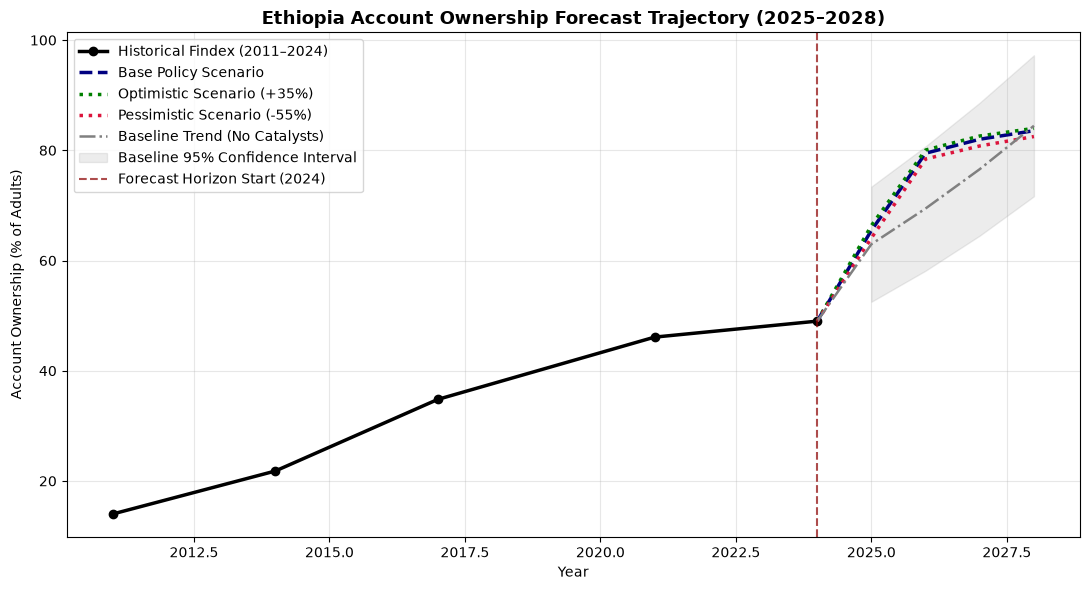

In [4]:
plt.figure(figsize=(11, 6))

# Plot Historical
plt.plot(hist_years, hist_account, "o-", color="black", lw=2.5, label="Historical Findex (2011–2024)")

# Plot Forecasts
all_years = np.append(2024, forecast_years)
acc_base_line = np.append(49.0, acc_base_scen)
acc_opt_line = np.append(49.0, acc_opt_scen)
acc_pess_line = np.append(49.0, acc_pess_scen)
acc_trend_line = np.append(49.0, base_acc)

plt.plot(all_years, acc_base_line, "--", color="navy", lw=2.5, label="Base Policy Scenario")
plt.plot(all_years, acc_opt_line, ":", color="green", lw=2.5, label="Optimistic Scenario (+35%)")
plt.plot(all_years, acc_pess_line, ":", color="crimson", lw=2.5, label="Pessimistic Scenario (-55%)")
plt.plot(all_years, acc_trend_line, "-.", color="gray", lw=1.8, label="Baseline Trend (No Catalysts)")

# Fill Confidence Region for Baseline
plt.fill_between(
    forecast_years, acc_low, acc_high, color="gray", alpha=0.15, label="Baseline 95% Confidence Interval"
)

plt.title("Ethiopia Account Ownership Forecast Trajectory (2025–2028)", fontsize=13, fontweight="bold")
plt.xlabel("Year")
plt.ylabel("Account Ownership (% of Adults)")
plt.axvline(2024, color="darkred", linestyle="--", alpha=0.7, label="Forecast Horizon Start (2024)")
plt.legend(loc="upper left")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("../reports/figures/account_ownership_forecast_scenarios.png")
plt.show()